In [1]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
PACKAGE_USED = 0  # 0 = sklearn; 1 = sktime; 2 = aeon

In [3]:
APPROACH = "rf"

In [4]:
CHANNEL_CONFIG = "g-a"

In [5]:
TRAIN_DIR = [
    R"dataset2"
]

In [6]:
TEST_DIR = [
    R"dataset2"
]

# Build DataFrame

In [7]:
def build_df(dirs):
    """
    dirs: list of directory paths containing CSV files
    """
    all_csv_files = []

    for _DIR in dirs:
        file_pattern = os.path.join(_DIR, "*.csv")
        csv_files = glob.glob(file_pattern)
        print(f"{_DIR} -> {len(csv_files)} CSV files found")
        all_csv_files.extend(csv_files)

    print(f"A total of {len(all_csv_files)} CSV files were used in constructing this DataFrame.")

    if not all_csv_files:
        raise ValueError("No CSV files found in the provided directories.")

    df = pd.concat((pd.read_csv(f) for f in all_csv_files), ignore_index=True)
    return df

In [8]:
df_train = build_df(TRAIN_DIR)

dataset2 -> 10 CSV files found
A total of 10 CSV files were used in constructing this DataFrame.


In [9]:
df_test = build_df(TEST_DIR)

dataset2 -> 10 CSV files found
A total of 10 CSV files were used in constructing this DataFrame.


In [10]:
print(df_train.duplicated().sum())

0


In [11]:
print(df_test.duplicated().sum())

0


In [12]:
df_train.drop_duplicates(inplace=True)

In [13]:
df_test.drop_duplicates(inplace=True)

## Remove unneeded columns

In [14]:
match CHANNEL_CONFIG:
    case "gyro":
        df_train = df_train.filter(regex=r'^(gyro|motion)')
        df_test = df_test.filter(regex=r'^(gyro|motion)')
    case "accel":
        df_train = df_train.filter(regex=r'^(acc|motion)')
        df_test = df_test.filter(regex=r'^(acc|motion)')
    case "mag":
        df_train = df_train.filter(regex=r'^(mag|motion)')
        df_test = df_test.filter(regex=r'^(mag|motion)')
    case "ahrs":
        df_train = df_train.filter(regex=r'^(ahrs|motion)')
        df_test = df_test.filter(regex=r'^(ahrs|motion)')
    case "g-a":
        df_train = df_train.filter(regex=r'^(gyro|acc|motion)')
        df_test = df_test.filter(regex=r'^(gyro|acc|motion)')
    case "g-m":
        df_train = df_train.filter(regex=r'^(gyro|mag|motion)')
        df_test = df_test.filter(regex=r'^(gyro|mag|motion)')
    case "a-m":
        df_train = df_train.filter(regex=r'^(acc|mag|motion)')
        df_test = df_test.filter(regex=r'^(acc|mag|motion)')
    case "g-a-m":
        df_train = df_train.filter(regex=r'^(gyro|acc|mag|motion)')
        df_test = df_test.filter(regex=r'^(gyro|acc|mag|motion)')
    case _:
        pass

In [15]:
# df_train = df_train.drop(df_train[df_train["motion_type"] == "POUR"].index)
# df_train = df_train.drop(df_train[df_train["motion_type"] == "TILT_UP"].index)
# df_train = df_train.drop(df_train[df_train["motion_type"] == "TILT_DOWN"].index)
# df_train = df_train.drop(df_train[df_train["motion_type"] == "STIR"].index)
# df_train = df_train.drop(df_train[df_train["motion_type"] == "ROLL"].index)


In [16]:
df_train.head()

,gyro_x_0,gyro_y_0,gyro_z_0,acc_x_0,acc_y_0,acc_z_0,gyro_x_1,gyro_y_1,gyro_z_1,acc_x_1,...,acc_x_28,acc_y_28,acc_z_28,gyro_x_29,gyro_y_29,gyro_z_29,acc_x_29,acc_y_29,acc_z_29,motion_type
0,-0.224537,-0.704687,-0.704687,0.124025,0.414425,0.414425,0.012925,-0.007425,-0.007425,1.52400,...,0.42495,1.83105,1.55505,11.904000,9.286051,7.054050,2.068050,1.477050,-1.09905,HIT
1,0.008662,-0.015675,-0.144650,0.018838,0.062287,0.122375,0.367125,0.361212,0.384175,1.43595,...,0.69300,2.18100,3.44805,10.696951,13.932001,14.161951,-7.567950,-1.720050,-1.44705,HIT
2,0.022550,0.024062,0.024062,0.479050,0.672650,0.672650,-0.025438,0.031350,0.031350,2.73600,...,3.01905,3.01905,2.66700,15.420001,15.420001,12.711000,-5.154000,-5.154000,-1.92600,HIT
3,0.396000,0.490737,0.490737,-0.777562,-1.041700,-1.041700,0.251900,0.345400,0.345400,3.31800,...,1.65105,3.41205,2.76300,13.435950,13.792951,11.752951,-1.327050,-2.701950,-4.23900,HIT
4,-0.734250,-1.149362,-1.381600,0.493625,0.483450,0.135988,0.587125,0.703038,0.763263,5.65305,...,-2.96505,-2.96505,1.00905,10.897950,10.897950,16.701000,-11.889001,-11.889001,-4.51005,HIT


In [17]:
df_test.head()

,gyro_x_0,gyro_y_0,gyro_z_0,acc_x_0,acc_y_0,acc_z_0,gyro_x_1,gyro_y_1,gyro_z_1,acc_x_1,...,acc_x_28,acc_y_28,acc_z_28,gyro_x_29,gyro_y_29,gyro_z_29,acc_x_29,acc_y_29,acc_z_29,motion_type
0,-0.224537,-0.704687,-0.704687,0.124025,0.414425,0.414425,0.012925,-0.007425,-0.007425,1.52400,...,0.42495,1.83105,1.55505,11.904000,9.286051,7.054050,2.068050,1.477050,-1.09905,HIT
1,0.008662,-0.015675,-0.144650,0.018838,0.062287,0.122375,0.367125,0.361212,0.384175,1.43595,...,0.69300,2.18100,3.44805,10.696951,13.932001,14.161951,-7.567950,-1.720050,-1.44705,HIT
2,0.022550,0.024062,0.024062,0.479050,0.672650,0.672650,-0.025438,0.031350,0.031350,2.73600,...,3.01905,3.01905,2.66700,15.420001,15.420001,12.711000,-5.154000,-5.154000,-1.92600,HIT
3,0.396000,0.490737,0.490737,-0.777562,-1.041700,-1.041700,0.251900,0.345400,0.345400,3.31800,...,1.65105,3.41205,2.76300,13.435950,13.792951,11.752951,-1.327050,-2.701950,-4.23900,HIT
4,-0.734250,-1.149362,-1.381600,0.493625,0.483450,0.135988,0.587125,0.703038,0.763263,5.65305,...,-2.96505,-2.96505,1.00905,10.897950,10.897950,16.701000,-11.889001,-11.889001,-4.51005,HIT


<Axes: xlabel='motion_type', ylabel='count'>

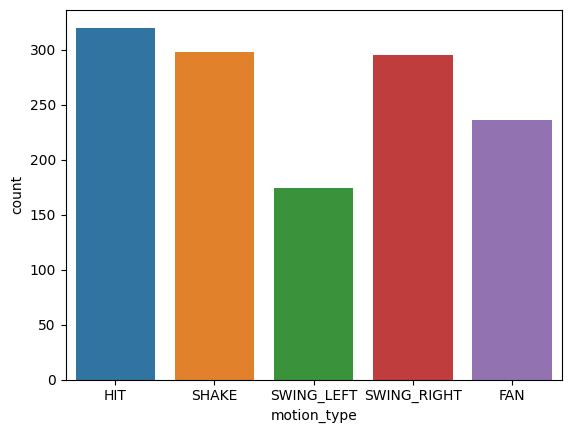

In [18]:
sns.countplot(df_train, x="motion_type", hue="motion_type")

In [19]:
len(df_train)

1323

<Axes: xlabel='motion_type', ylabel='count'>

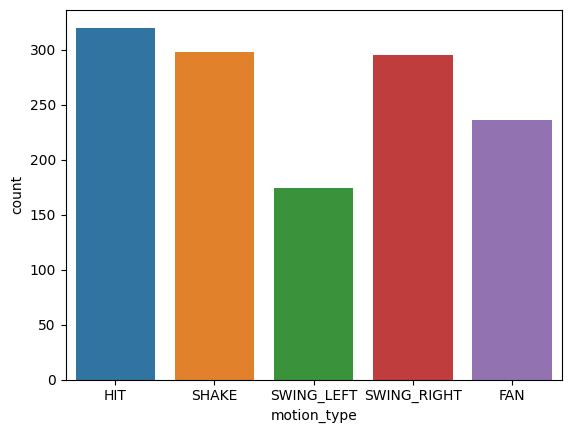

In [20]:
sns.countplot(df_test, x="motion_type", hue="motion_type")

In [21]:
len(df_test)

1323

## Get X and y

In [22]:
from sklearn.preprocessing import LabelEncoder

In [23]:
def get_X_and_y(df: pd.DataFrame, package_used: int) -> tuple[np.array, np.array]:
    if package_used == 0:  # sklearn
        X = df.drop(columns=["motion_type"]).values
        y = df["motion_type"].values
        return X.astype("float32"), y
    
    elif package_used == 1:  # sktime
        X_df = df.drop(columns=["motion_type"])
        y = df["motion_type"].values
        
        n_timesteps = 30
        channels = []
        match CHANNEL_CONFIG:
            case "accel":
                channels = ["accel_x", "accel_y", "accel_z"]
            case "gyro":
                channels = ["gyro_x", "gyro_y", "gyro_z"]
            case "mag":
                channels = ["mag_x", "mag_y", "mag_z"]
            case "ahrs":
                channels = ["ahrs_x", "ahrs_y", "ahrs_z", "ahrs_w"]
            case "g-a":
                channels = ["gyro_x", "gyro_y", "gyro_z", "accel_x", "accel_y", "accel_z"]
            case "g-m":
                channels = ["gyro_x", "gyro_y", "gyro_z", "mag_x", "mag_y", "mag_z"]
            case "a-m":
                channels = ["accel_x", "accel_y", "accel_z", "mag_x", "mag_y", "mag_z"]
            case "g-a-m":
                channels = ["gyro_x", "gyro_y", "gyro_z", "accel_x", "accel_y", "accel_z", "mag_x", "mag_y", "mag_z"]
            case _:
                channels = ["gyro_x", "gyro_y", "gyro_z", "accel_x", "accel_y", "accel_z", "mag_x", "mag_y", "mag_z", "ahrs_x", "ahrs_y", "ahrs_z", "ahrs_w"]
        n_channels = len(channels)

        X = np.zeros((len(df), n_channels, n_timesteps))

        for t in range(n_timesteps):
            for c, channel in enumerate(channels):
                col_name = f"{channel}_{t}"
        
                X[:, c, t] = X_df[col_name].values
                
        return X.astype("float32"), y

    else:  # aeon
        y = df["motion_type"].values

        n_timesteps = 30

        channels = {
            "accel": ["accel_x", "accel_y", "accel_z"],
            "gyro": ["gyro_x", "gyro_y", "gyro_z"],
            "mag": ["mag_x", "mag_y", "mag_z"],
            "ahrs": ["ahrs_x", "ahrs_y", "ahrs_z", "ahrs_w"],
            "g-a": ["gyro_x", "gyro_y", "gyro_z", "accel_x", "accel_y", "accel_z"],
            "g-m": ["gyro_x", "gyro_y", "gyro_z", "mag_x", "mag_y", "mag_z"],
            "a-m": ["accel_x", "accel_y", "accel_z", "mag_x", "mag_y", "mag_z"],
            "g-a-m": ["gyro_x", "gyro_y", "gyro_z",
                    "accel_x", "accel_y", "accel_z",
                    "mag_x", "mag_y", "mag_z"],
        }.get(CHANNEL_CONFIG, [
            "gyro_x","gyro_y","gyro_z",
            "accel_x","accel_y","accel_z",
            "mag_x","mag_y","mag_z",
            "ahrs_x","ahrs_y","ahrs_z","ahrs_w"
        ])

        n_channels = len(channels)
        X = np.zeros((len(df), n_channels, n_timesteps), dtype="float32")

        for t in range(n_timesteps):
            for c, ch in enumerate(channels):
                X[:, c, t] = df[f"{ch}_{t}"].values

        return X.astype("float32"), y

In [24]:
X_train, y_train = get_X_and_y(df_train, PACKAGE_USED)
X_test, y_test = get_X_and_y(df_test, PACKAGE_USED)

In [25]:
X_train.shape

(1323, 180)

In [26]:
y_train

array(['HIT', 'HIT', 'HIT', ..., 'FAN', 'FAN', 'FAN'], dtype=object)

In [ ]:
mapping = {'HIT': 0, 'SHAKE': 1, 'SWING_LEFT': 2, 'SWING_RIGHT': 3, 'FAN': 4, 'IDLE': 5, 'STIR': 6, 'LIFt': 7, 'SPIN': 8, 'STIR': 9}
y_train = np.vectorize(mapping.get)(y_train)
y_test = np.vectorize(mapping.get)(y_test)

In [28]:
# from sktime.classification.kernel_based import RocketClassifier
from sktime.transformations.panel.rocket import MiniRocketMultivariate
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sktime.classification.distance_based import KNeighborsTimeSeriesClassifier
# from sktime.classification.deep_learning import InceptionTimeClassifier
from sklearn.pipeline import make_pipeline
# from sklearn.preprocessing import StandardScaler
# from xgboost import XGBClassifier
from aeon.classification.deep_learning import LITETimeClassifier

ModuleNotFoundError: No module named 'sktime'

In [ ]:
if PACKAGE_USED == 0:
    if APPROACH.lower() == "svm":
        clf_minirocket = SVC()
    elif APPROACH.lower() == "rf":
        clf_minirocket = RandomForestClassifier()
    elif APPROACH.lower() == "softmax":
        clf_minirocket = LogisticRegression()

In [ ]:
if PACKAGE_USED == 1:
    if APPROACH.lower() == "knn":
        clf_minirocket = KNeighborsTimeSeriesClassifier(n_neighbors=1, distance="dtw")
    elif APPROACH.lower() == "minirocket":
        clf_minirocket = make_pipeline(
            MiniRocketMultivariate(random_state=42),
            RidgeClassifier(alpha=1.0)
        )

In [ ]:
if PACKAGE_USED == 2:
    if APPROACH.lower() == "litemvtime":
        clf_minirocket = LITETimeClassifier(use_litemv=True)

In [ ]:
clf_minirocket.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

In [ ]:
y_pred_train = clf_minirocket.predict(X_train)

In [ ]:
print(accuracy_score(y_train, y_pred_train))
print(precision_score(y_train, y_pred_train, average="weighted"))
print(recall_score(y_train, y_pred_train, average="weighted"))
print(f1_score(y_train, y_pred_train, average="weighted"))

In [ ]:
y_pred_test = clf_minirocket.predict(X_test)

In [ ]:
print(accuracy_score(y_test, y_pred_test))
print(precision_score(y_test, y_pred_test, average="weighted", zero_division=0))
print(recall_score(y_test, y_pred_test, average="weighted", zero_division=0))
print(f1_score(y_test, y_pred_test, average="weighted", zero_division=0))

In [ ]:
cm = confusion_matrix(y_test, y_pred_test)
print(cm)

In [ ]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

class_names = le.classes_.tolist()

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,              # use cm for raw counts
    annot=True,                 # write numbers inside cells
    fmt=".2f",                  # 2 decimal places
    cmap="Blues",               # color style
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.savefig(f"cmat_{APPROACH}.png")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test, y_pred_test))

In [ ]:
from time import perf_counter

In [ ]:
t0 = perf_counter()
a = clf_minirocket.predict(X_train[0:1])
t1 = perf_counter()

In [ ]:
print(f"{t1 - t0} seconds taken to perform a single inference!")

In [ ]:
from skl2onnx import to_onnx

if PACKAGE_USED == 0:
    onx = to_onnx(clf_minirocket, X_train[:1])
    with open(f"clf_{APPROACH}.onnx", "wb") as f:
        f.write(onx.SerializeToString())

In [ ]:
from joblib import dump

dump(clf_minirocket, f"clf_{APPROACH}.joblib")

In [ ]:
# clf_minirocket.predict(X_train[0:1])

In [ ]:
# print(repr(X_train[0:1]))

In [ ]:
# print(repr(y_train[0]))